# 05 · Yankees baserunning and defense, 2017–2026

Team-level context for the hitter notebooks: how much value the Yankees gained or lost on the bases and in the field each season, and where that ranked in MLB. All figures are FanGraphs team totals, pulled from the FanGraphs leaders API.

**Definitions.** BsR is total baserunning runs above average (stolen-base runs wSB, plus UBR for other advancement, plus double-play avoidance wGDP). OAA (Outs Above Average, Statcast) and DRS (Defensive Runs Saved, Sports Info Solutions) are separate fielding systems built on different data, and they can disagree. Rank 1 is the best in MLB.

**Caveats.** 2020 was a 60-game season, so its counting totals are not comparable with other years. The FanGraphs API returns no UBR for 2025 or 2026, so those seasons show BsR without the UBR split.

In [1]:
import sys
import warnings

warnings.filterwarnings("ignore", message=".*urllib3.*")
sys.path.insert(0, "../src")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("../outputs/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 3)

from yanks_analytics.data.statcast import get_team_batting_stats, get_team_fielding_stats
from yanks_analytics.features.team import merge_team_batting_fielding

SEASONS = range(2017, 2027)

In [2]:
batting = pd.concat([get_team_batting_stats(s).assign(Season=s) for s in SEASONS], ignore_index=True)
fielding = pd.concat([get_team_fielding_stats(s).assign(Season=s) for s in SEASONS], ignore_index=True)
teams = merge_team_batting_fielding(batting, fielding)
print(teams.groupby("Season").size().to_string())

Season
2017    30
2018    30
2019    30
2020    30
2021    30
2022    30
2023    30
2024    30
2025    30
2026    30


In [3]:
COLS = ["BsR", "wSB", "UBR", "SB", "CS", "OAA", "DRS"]
for col in ["BsR", "wSB", "UBR", "OAA", "DRS"]:
    teams[f"{col}_rank"] = teams.groupby("Season")[col].rank(ascending=False, method="min")

nyy = teams[teams["Team"] == "NYY"].set_index("Season")
table = nyy[["BsR", "BsR_rank", "wSB", "UBR", "UBR_rank", "SB", "CS", "OAA", "OAA_rank", "DRS", "DRS_rank"]]
table.to_csv(DATA_DIR / "yankees_baserunning_defense.csv")
table.style.format({c: "{:+.1f}" for c in ["BsR", "wSB", "UBR"]}
                   | {c: "{:.0f}" for c in table.columns if c.endswith("_rank") or c in ("SB", "CS")}
                   | {"OAA": "{:+.0f}", "DRS": "{:+.0f}"}, na_rep="n/a")

,BsR,BsR_rank,wSB,UBR,UBR_rank,SB,CS,OAA,OAA_rank,DRS,DRS_rank
Season,,,,,,,,,,,
2017,+7.5,7,+4.7,+0.7,19,90,22,+19,7,+29,12
2018,+2.1,13,+0.4,+9.7,3,63,21,-35,26,+36,9
2019,-2.1,16,-1.8,+0.2,16,55,22,-37,30,-14,20
2020,-0.2,15,+0.6,+6.9,3,27,7,-9,23,-1,19
2021,-3.8,20,-0.0,-3.7,23,63,18,-22,24,-41,27
2022,-6.2,24,+1.2,-8.7,27,102,33,+21,5,+124,1
2023,-11.6,28,-3.0,-8.5,26,100,30,+2,12,+29,10
2024,-17.1,30,-5.2,-10.9,29,88,26,+10,10,+31,12
2025,-4.7,22,+1.5,n/a,n/a,134,38,-7,18,+30,12


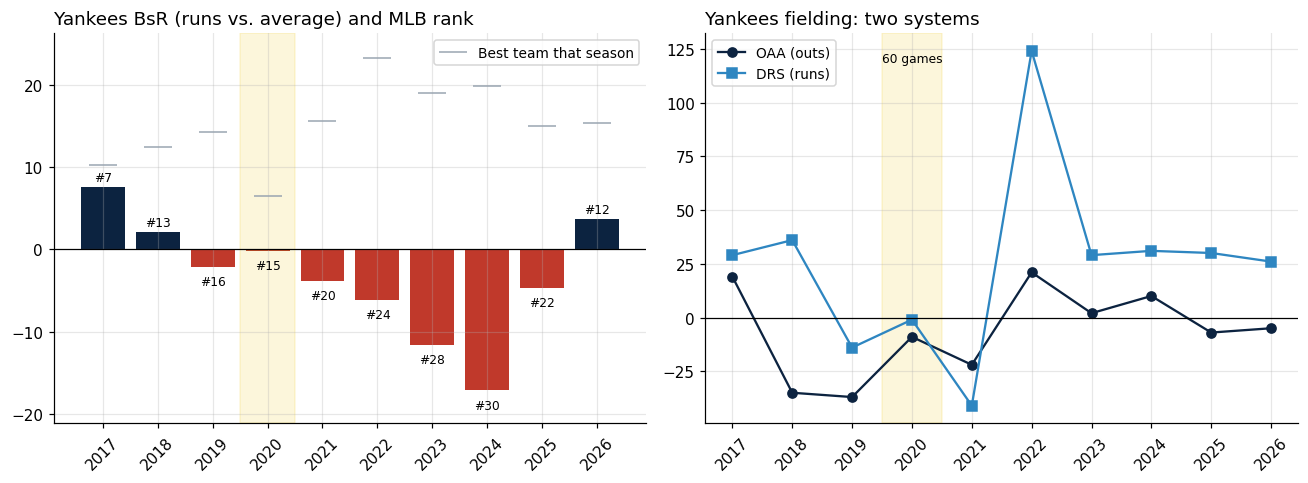

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
years = list(SEASONS)
league_best = teams.groupby("Season")["BsR"].max()
axes[0].bar(years, nyy["BsR"], color=np.where(nyy["BsR"] >= 0, "#0c2340", "#c0392b"))
axes[0].plot(years, league_best, color="#9aa5b1", marker="_", markersize=18, linestyle="none",
             label="Best team that season")
for yr in years:
    axes[0].annotate(f"#{int(nyy.loc[yr, 'BsR_rank'])}", (yr, nyy.loc[yr, "BsR"]),
                     textcoords="offset points", xytext=(0, 4 if nyy.loc[yr, "BsR"] >= 0 else -12),
                     ha="center", fontsize=8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylim(nyy["BsR"].min() - 4, league_best.max() + 3)
axes[0].set_title("Yankees BsR (runs vs. average) and MLB rank", loc="left")
axes[0].legend(loc="upper right", fontsize=9)

axes[1].plot(years, nyy["OAA"], marker="o", color="#0c2340", label="OAA (outs)")
axes[1].plot(years, nyy["DRS"], marker="s", color="#2e86c1", label="DRS (runs)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Yankees fielding: two systems", loc="left")
axes[1].legend(loc="upper left", fontsize=9)
for ax in axes:
    ax.set_xticks(years, [str(y) for y in years], rotation=45)
    ax.axvspan(2019.5, 2020.5, color="#f1c40f", alpha=0.15)
axes[1].text(2020, axes[1].get_ylim()[1] * 0.9, "60 games", ha="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "yankees_baserunning_defense.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
r = teams[["OAA", "DRS"]].corr().iloc[0, 1]
disagree = teams[(np.sign(teams["OAA"]) != np.sign(teams["DRS"])) & (teams[["OAA", "DRS"]].abs().min(axis=1) >= 10)]
print(f"OAA vs DRS across {len(teams)} team-seasons: r = {r:.2f}")
print(f"Team-seasons where the systems disagree in sign by 10+ each: {len(disagree)}")
disagree[["Season", "Team", "OAA", "DRS"]].sort_values("Season").reset_index(drop=True)

OAA vs DRS across 300 team-seasons: r = 0.61
Team-seasons where the systems disagree in sign by 10+ each: 33


,Season,Team,OAA,DRS
0,2017,LAD,-21.0,73.0
1,2017,STL,-11.0,39.0
2,2017,KCR,16.0,-51.0
3,2017,PIT,-16.0,30.0
4,2017,SDP,-30.0,15.0
5,2018,CIN,16.0,-16.0
6,2018,SEA,-11.0,14.0
7,2018,TEX,11.0,-30.0
8,2018,LAD,-13.0,60.0
9,2018,NYY,-35.0,36.0


In [6]:
span = nyy.loc[2021:2024]
print("Yankees 2021-2024 totals: "
      f"BsR {span['BsR'].sum():+.1f}, UBR {span['UBR'].sum():+.1f}, wSB {span['wSB'].sum():+.1f}")
print(f"Stolen bases by season: {nyy['SB'].astype(int).to_dict()}")

Yankees 2021-2024 totals: BsR -38.7, UBR -31.8, wSB -7.0
Stolen bases by season: {2017: 90, 2018: 63, 2019: 55, 2020: 27, 2021: 63, 2022: 102, 2023: 100, 2024: 88, 2025: 134, 2026: 153}


## Findings

- **Baserunning value fell from 2017 to 2024, then recovered.** BsR went from +7.5 runs in 2017 (7th in MLB) to −17.1 in 2024 (30th). It climbed to −4.7 in 2025 (22nd) and +3.7 in 2026 (12th).
- **The 2021–2024 decline came mostly from advancement rather than stolen bases.** Over those four seasons BsR totaled −38.7 runs, of which UBR accounted for −31.8 and wSB for −7.0. The team stole 102 and 100 bases in 2022 and 2023 while BsR kept falling.
- **The recovery coincided with more running.** The Yankees stole 134 bases in 2025 and 153 in 2026, the two highest totals in this ten-season window. Without UBR for those seasons, the data cannot say whether advancement on balls in play also improved.
- **Fielding depends on which system you read.** By OAA the Yankees ranked 26th, 30th, 23rd, and 24th from 2018 to 2021. DRS agreed for 2019–2021 but had 2018 at +36 (9th) against OAA's −35. Both systems had 2022 as a strong year (OAA +21, 5th; DRS +124, 1st), and both place 2023–2026 in the middle of the league.
- **The two fielding systems correlate at r = .61 league-wide** and disagree in sign by 10+ in 33 of 300 team-seasons, so a single system should not carry a defensive conclusion.

This is a record of results, not an explanation of them: roster changes, player health, and park all move these totals, and public data cannot attribute a season's baserunning or defense to specific decisions.